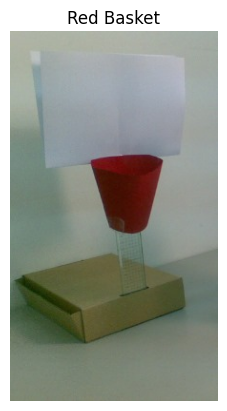

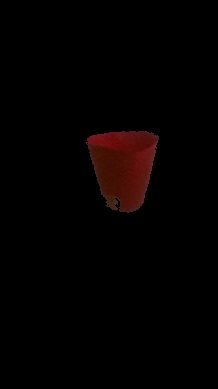

In [ ]:
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

redbasket=cv2.imread('/content/WhatsApp Image 2026-04-08 at 21.25.12.jpeg')
plt.imshow(cv2.cvtColor(redbasket, cv2.COLOR_BGR2RGB))
plt.title("Red Basket")
plt.axis('off')
plt.show()

redrgb = cv2.cvtColor(redbasket,cv2.COLOR_BGR2RGB)
lower_red1 = np.array([50, 0, 0])
upper_red1 = np.array([255,45, 45])
mask1 = cv2.inRange(redrgb, lower_red1, upper_red1)
res = cv2.bitwise_and(redbasket,redbasket, mask= mask1)
gray=cv2.cvtColor(res,cv2.COLOR_BGR2GRAY)

cv2_imshow(res)

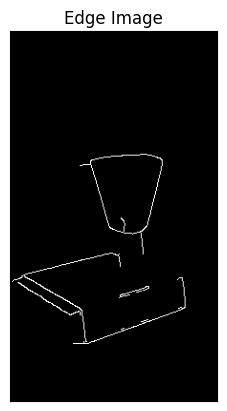

In [ ]:
edges = cv2.Canny(redbasket,100,200)

# plt.subplot(121),plt.imshow(img,cmap = 'gray')
# plt.title('Original Image'), plt.xticks([]), plt.yticks([])

plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])

plt.show()

array([[[176, 180, 165],
        [175, 179, 164],
        [174, 178, 163],
        ...,
        [162, 173, 165],
        [159, 170, 162],
        [159, 170, 162]],

       [[178, 182, 167],
        [178, 182, 167],
        [177, 181, 166],
        ...,
        [163, 174, 166],
        [162, 173, 165],
        [162, 173, 165]],

       [[180, 184, 170],
        [179, 183, 169],
        [178, 182, 168],
        ...,
        [163, 174, 166],
        [163, 174, 166],
        [163, 174, 166]],

       ...,

       [[127, 136, 115],
        [126, 135, 114],
        [126, 135, 114],
        ...,
        [132, 139, 123],
        [134, 141, 125],
        [134, 141, 125]],

       [[127, 136, 115],
        [126, 135, 114],
        [125, 134, 113],
        ...,
        [132, 139, 123],
        [135, 142, 126],
        [135, 142, 126]],

       [[126, 135, 116],
        [125, 134, 115],
        [124, 133, 112],
        ...,
        [133, 140, 124],
        [135, 142, 126],
        [135, 142, 126]]], dtype=uint8)
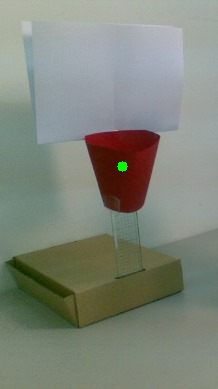

In [ ]:
kernel = np.ones((5,5), np.uint8)
mask1 = cv2.morphologyEx(mask1, cv2.MORPH_CLOSE, kernel)
contours, _ = cv2.findContours(mask1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(contours, key=cv2.contourArea)
M = cv2.moments(cnt)
cx = int(M["m10"] / M["m00"])
cy = int(M["m01"] / M["m00"])
cv2.circle(redrgb, (cx, cy), 5, (0,255,0), -1)